# Spectral Cutting EDA

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import loompy
import networkx as nx
from IPython.display import display

# Helper Methods

## Go Functions

In [11]:
def get_genes_from_go_path(go_pathname, file_path="../../../resources/GO_Biological_Process_2023.txt"):
    """
    Reads a tab-delimited file where each line starts with a GO pathway name,
    then returns a list of genes in the row where the pathway name matches `go_pathname`.
    """
    with open(file_path, 'r') as f:
        for line in f:
            # Remove newline and split by tab
            parts = line.strip().split('\t')
            # The first column is the pathway name
            if parts[0].strip() == go_pathname.strip():
                # Genes are all non-empty fields after the first two columns
                # (since there are 2 tabs after the pathway name in your file)
                genes = [x for x in parts[2:] if x]
                return genes
    return []

def search_go_pathways(search_str, file_path="../../../resources/GO_Biological_Process_2023.txt"):
    """
    Returns a list of pathway names containing `search_str` (case-insensitive).
    """
    pathways = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if search_str.lower() in parts[0].lower():
                pathways.append(parts[0])
    return pathways


def pathways_with_genes(gene_list, file_path="../../../resources/GO_Biological_Process_2023.txt"):
    """
    Returns all pathways where every gene in `gene_list` is present in that pathway's gene set.
    """
    results = []
    genes_set = set(gene_list)
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway = parts[0]
            # Genes start after two tab columns
            pathway_genes = set([x for x in parts[2:] if x])
            if genes_set.issubset(pathway_genes):
                results.append(pathway)
    return results


# results = search_go_pathways("cell cycle")
# print("First 5 pathways containing 'cell cycle':")
# print(results[:5])

# gene_list = get_genes_from_go_path(results[0])
# print(f"\nGenes in pathway '{results[0]}':")
# print(gene_list)

# results_with_cd34 = pathways_with_genes(['CD34'])
# print("\nFirst 5 pathways containing gene 'CD34':")
# print(results_with_cd34[:5])

## Load Gene Lists

In [13]:
# load tfs so I got 'em
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:5]

['ZNF354C', 'KLF12', 'ZNF143', 'ZIC2', 'ZNF274']

In [14]:
fpath = "../../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
mdf['val'] = 1
print(mdf.head().to_string(index=False))

gene_name         cell_type  is_tf  source    category  val
   TSPAN8 endothelial_cells  False panglao endothelial    1
     KLK1 endothelial_cells  False panglao endothelial    1
   RNASE1 endothelial_cells  False panglao endothelial    1
      LUM endothelial_cells  False panglao endothelial    1
      LOX endothelial_cells  False panglao endothelial    1


In [15]:
mdf_pivot = pd.pivot_table(
    mdf, 
    index=['gene_name',],
    columns=['source', 'category'],
    values='val',
    fill_value=0
)

mdf_pivot.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in mdf_pivot.columns]

mdf_pivot.head()

,panglao_endothelial,panglao_fibroblast,panglao_hematopoietic,tabula_endothelial,tabula_fibroblast,tabula_hematopoietic
gene_name,,,,,,
A2M,1.0,0.0,0.0,1.0,1.0,0.0
ABCA8,1.0,0.0,0.0,0.0,0.0,0.0
ABCB1,0.0,0.0,1.0,0.0,0.0,0.0
ABCG2,1.0,0.0,1.0,0.0,0.0,0.0
ABI3,0.0,1.0,0.0,0.0,0.0,0.0


# Load Networks

In [2]:
# Dictionary to store data
data = {}

## SCENIC

In [3]:
# Set base path
base_path = '/scratch/indikar_root/indikar1/shared_data/scenic/hsc'

# Find all cluster folders
cluster_dirs = sorted(glob.glob(os.path.join(base_path, 'hsc_c*')))
print(f"Found {len(cluster_dirs)} cluster directories.")

scenic_data = {}
for cluster_path in cluster_dirs:
    cluster_name = os.path.basename(cluster_path)    
    adj_file = os.path.join(cluster_path, 'adj.tsv')
    
    # Load adjacency file
    adj_df = pd.read_csv(adj_file, sep='\t') # , header=None, names=['TF', 'Target', 'Importance'])
    adj_df.columns = ["n1", "n2", "weight"]
    
    # Store in dictionary
    scenic_data[cluster_name] = {
        'adjacency_list': adj_df,
    }

Found 5 cluster directories.


In [4]:
scenic_data.keys()

dict_keys(['hsc_c1', 'hsc_c2', 'hsc_c3', 'hsc_c4', 'hsc_c5'])

## scMINER

In [5]:
scminer_files = [
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C1/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C2/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C3/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C4/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C5/output/consensus_network_ncol_.txt"
]

scminer_data = {}
key_names = ['hsc_c1', 'hsc_c2', 'hsc_c3', 'hsc_c4', 'hsc_c5']
for ifile, file in enumerate(scminer_files):
    adj_df = pd.read_csv(file, sep='\t')
    adj_df = adj_df[["source", "target"]]
    adj_df.columns = ['n1', 'n2']
    adj_df['weight'] = 1
    scminer_data[key_names[ifile]] = {
        'adjacency_list': adj_df,
    }

In [6]:
scminer_data.keys()

dict_keys(['hsc_c1', 'hsc_c2', 'hsc_c3', 'hsc_c4', 'hsc_c5'])

In [7]:
data = {
    "scenic": scenic_data,
    "scminer": scminer_data
}

# CellMarker_2024 Gene Lists

In [8]:
first_column, second_column = [], []
with open("../../resources/CellMarker_2024.txt", "r") as file:
    for line in file:
        # Split on tabs and remove empty strings
        parts = [p for p in line.strip().split('\t') if p]
        if not parts:
            continue
        first_column.append(parts[0])
        second_column.append(parts[1:])  # Everything after the first element

cell_marker_genes = pd.DataFrame({
    'cell_type': first_column,
    'marker_genes': second_column
})

hsc_markers = cell_marker_genes[cell_marker_genes['cell_type'] == "Hematopoietic Stem Cell Bone Marrow Human"]['marker_genes'].values[0]

In [63]:
dataset

'scminer'

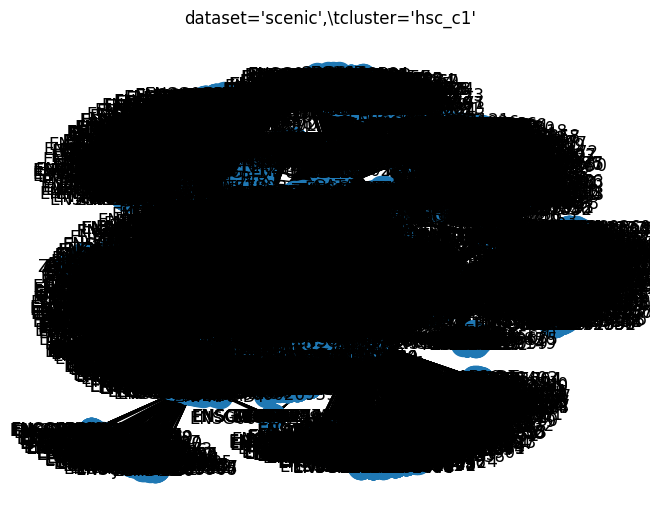


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x151318eeeb60> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



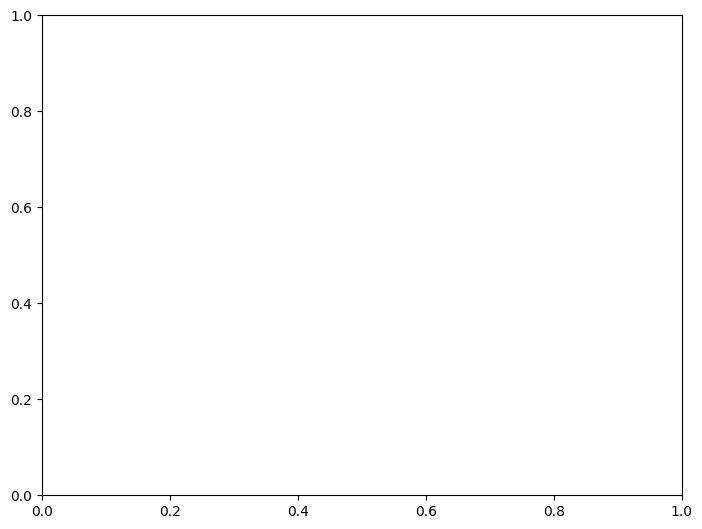

In [9]:
for dataset, cluster in ((d, c) for d in data for c in data[d]):
    adj_df = data[dataset][cluster]["adjacency_list"]
    gene_target_adj_df = adj_df[adj_df['n1'].isin(hsc_markers) | adj_df['n2'].isin(hsc_markers)]
    
    G = nx.Graph()  # or nx.DiGraph()
    edges = gene_target_adj_df[['n1', 'n2']].itertuples(index=False, name=None)
    G.add_edges_from(edges)
    nx.draw(G, with_labels=True)
    plt.title(f"{dataset=},\t{cluster=}")
    plt.show()


KeyboardInterrupt



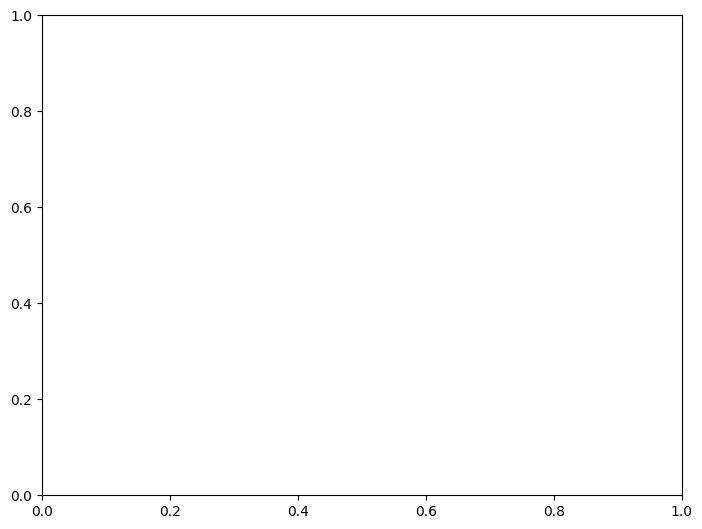

In [10]:
    nx.draw(G, with_labels=False)


In [55]:
G = nx.Graph()  # or nx.DiGraph()
edges = gene_target_adj_df[['n1', 'n2']].itertuples(index=False, name=None)
G.add_edges_from(edges)
nx.draw(G, with_labels=True)

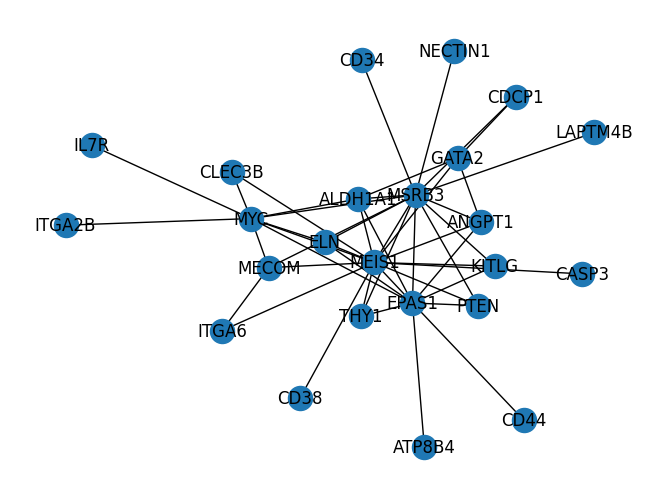

In [59]:
nx.draw(G, with_labels=True)

# Scratch

In [67]:
adj_df['n1']

0         AATF
1         AATF
2         AATF
3         AATF
4         AATF
          ... 
125937    ZZZ3
125938    ZZZ3
125939    ZZZ3
125940    ZZZ3
125941    ZZZ3
Name: n1, Length: 125942, dtype: object